# Ehrapy Imputation Methods Benchmark on PhysioNet2012 Dataset

 Missing data is common in EHR datasets. This tutorial demonstrates ehrapy's imputation methods, their trade-offs, and their performance on the PhysioNet Challenge 2012 ICU dataset, so you can make an informed choice for your own analysis.
 


## 1. Imputation Methods within ehrapy

Before we start, let's get an overview of what imputation methods ehrapy has to offer:

``explicit_impute`` replaces every missing value with a fixed constant (e.g. 0). It is the fastest option and useful when the constant has a clinical meaning — for example, a missing drug dose genuinely being zero. It should not be used as a general-purpose strategy since it distorts all downstream statistics.

``simple_impute`` fills missing values with a column-level statistic: mean, median, or most-frequent value. It is fast and deterministic but ignores relationships between variables, and it shrinks the variance of imputed columns.

``locf_impute`` (Last Observation Carried Forward) fills each missing timepoint with the most recent observed value for that patient and variable. It is the most clinically natural baseline for time-series EHR data — it assumes a measurement stays constant until the next observation, which often reflects how ICU values actually behave. It cannot fill the first timepoint if no prior value exists.

``knn_impute`` finds the k nearest patients (by their non-missing values) and uses the mean of their values to fill each gap. It captures cross-patient similarity, but scales poorly to large datasets.

``miss_forest_impute`` iteratively fits a random forest to predict each variable from all others, repeating until convergence. It is one of the strongest classical methods, it handles non-linear relationships between variables well, but is slower than the methods above.

``mice_forest_impute`` models each variable as a function of all others in a round-robin fashion using LightGBM across multiple iterations. Statistically principled and can produce multiple imputed datasets to propagate uncertainty downstream, at the cost of being the slowest method.

## 1. Environmental Setup

So that we can compare these methods, first we need to set up our environment.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
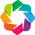

In [1]:
import ehrapy as ep
import ehrdata as ed 
import numpy as np
import pandas as pd

In [2]:
import warnings

warnings.filterwarnings("ignore")
ep.settings.verbosity = "error"

## 2. Load PhysioNet2012 Dataset

For this analysis, we choose PhysioNet2012 dataset. It has a heterogeneous missingness pattern and contains hourly ICU measurements, which make the dataset a representative case in real life and shows challenges coming from time-series data. More overview on the dataset, you can find here: https://physionet.org/content/challenge-2012/1.0.0/

In [3]:
edata = ed.dt.physionet2012(layer="tem_data")
edata

View of EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    layers: 'tem_data'
    shape of .tem_data: (11988, 37, 48)

## 3. Inspect Missingness on the Full Dataset

Before getting started with looking at the imputation methods and imputing the whole dataset, it is worth understanding the structure of the missing data. `ep.pp.qc_metrics` computes per-variable and per-observation missingness statistics and stores them in `edata.var` and `edata.obs`. 

After running it, inspect `edata.var`: variables with >80% missingness are often better dropped than imputed. 

In [4]:
ep.pp.qc_metrics(edata, layer="tem_data")

(          missing_values_abs  missing_values_pct  entropy_of_missingness
 RecordID                                                                
 132539                  1516           85.360360                0.600748
 132540                  1375           77.421171                0.770597
 132541                  1383           77.871622                0.762505
 132543                  1418           79.842342                0.725070
 132545                  1472           82.882883                0.660377
 ...                      ...                 ...                     ...
 163029                  1438           80.968468                0.702131
 163033                  1592           89.639640                0.480316
 163034                  1402           78.941441                0.742601
 163035                  1410           79.391892                0.733925
 163037                  1310           73.761261                0.830328
 
 [11988 rows x 3 columns],
         

## 4. Set Up the Benchmark

### 4.1 Create a subset of the dataset

First we want to quantitatively compare methods before applying a specific one to the full dataset. To do that in a manageable computitional runtime, we will use a subset of 200 observations. 

In [5]:
edata_bench = edata[:200] #200 patient subset 

To quantitatively compare methods, we work on a subset of 200 observations to keep runtimes manageable. We mask 10% of the already-observed values (creating artificial NaNs with a known ground truth) then run each method on an independent copy and compare:

- MAE on the held-out positions (accuracy)
- mean and standard deviation differences (distribution preservation)
- runtime and peak memory usage (computational cost)

We use this masking strategy because real-world NaNs in the dataset have no ground truth, so direct accuracy evaluation on them is impossible.

In [6]:
full_layer = edata_bench.layers["tem_data"].copy() #ground truth

rng = np.random.default_rng(42)
non_nan_mask = ~np.isnan(full_layer)
mask_indices = np.where(non_nan_mask)
n_to_mask = int(0.1 * len(mask_indices[0]))
chosen = rng.choice(len(mask_indices[0]), size=n_to_mask, replace=False)

masked_layer = full_layer.copy()
masked_layer[
    mask_indices[0][chosen], 
    mask_indices[1][chosen], 
    mask_indices[2][chosen]
            ] = np.nan

edata_bench.layers["tem_data"] = masked_layer

# Boolean mask
introduced_mask = np.zeros(full_layer.shape, dtype=bool)
introduced_mask[
    mask_indices[0][chosen], 
    mask_indices[1][chosen], 
    mask_indices[2][chosen]
            ] = True

### 4.2 Run Imputation Methods

Each imputation method gets an independent copy of the masked layer of the subset edata so they don't interfere with each other. 

After imputing, we save the evaluation metrics in the results dictionary to be able to see the results clearly.

In [7]:
edata_explicit = edata_bench.copy()
ep.pp.explicit_impute(edata=edata_explicit, layer="tem_data", replacement=0)

In [8]:
edata_simple = edata_bench.copy()
ep.pp.simple_impute(edata=edata_simple, layer="tem_data", strategy="mean")

In [9]:
edata_knn = edata_bench.copy()
ep.pp.knn_impute(edata=edata_knn, layer="tem_data")

In [10]:
edata_miss_forest = edata_bench.copy()
ep.pp.miss_forest_impute(edata=edata_miss_forest, layer="tem_data")

In [11]:
edata_mice_forest = edata_bench.copy()
ep.pp.mice_forest_impute(edata=edata_mice_forest, layer="tem_data")

In [12]:
edata_locf = edata_bench.copy()
ep.pp.locf_impute(edata=edata_locf, layer="tem_data")

### 4.3 Evaluation

We evaluate each imputation method across three dimensions: accuracy against the held-out ground truth, preservation of the variable distributions, and computational cost.


#### 4.3.1 Accuracy Metrics

**RMSE and MAE:** how close the imputed values are to the held-out ground truth


For using these metrics, we need an evaluation method.

In [13]:
def evaluate(imputed_edata):
    from sklearn.metrics import root_mean_squared_error
    from sklearn.metrics import mean_absolute_error

    y_pred = imputed_edata.layers["tem_data"][introduced_mask]
    y_true = full_layer[introduced_mask]
    return {
        "RMSE": float(root_mean_squared_error(y_true=y_true, y_pred=y_pred)),
        "MAE": float(mean_absolute_error(y_true=y_true, y_pred=y_pred)),
        "mean_diff": float(np.abs(np.nanmean(y_pred) - np.nanmean(y_true))),
        "std_diff":  float(np.abs(np.nanstd(y_pred) - np.nanstd(y_true))),
    }

To save the results of our metrics, let's create a dictionary:

In [14]:
results = {}

results["explicit_impute"] = evaluate(edata_explicit)
results["simple_impute"] = evaluate(edata_simple)
results["knn_impute"] = evaluate(edata_knn)
results["miss_forest_impute"] = evaluate(edata_miss_forest)
results["mice_forest_impute"] = evaluate(edata_mice_forest)
results["locf_impute"] = evaluate(edata_locf)

Now we can see how each method's imputation values deviate from the ground truth values:

In [15]:
df_results = pd.DataFrame(results).T
df_results.index.name = "Method"
df_results

,RMSE,MAE,mean_diff,std_diff
Method,,,,
explicit_impute,91.717967,70.792563,70.792012,58.315320
simple_impute,43.244451,18.786436,0.975423,16.462481
knn_impute,42.743747,17.316236,0.480261,16.638894
miss_forest_impute,39.122351,13.759423,1.074179,13.323156
mice_forest_impute,55.771292,19.206561,0.633422,0.592466
locf_impute,39.664812,12.497735,0.694644,0.362348


#### 4.3.2 Distribution Preservation

An imputation method can have a low RMSE but still shift the mean or collapse the variance. Hence, we have to make sure that the statistical properties of the original data is also maintained in a population level after filling in missing values. For that we look at the **mean difference and standard deviation difference** which tell us how well the method preserves the global statistics of each variable.

We use raincloud plots to compare the statistical distribution of each variable before and after imputation across all methods.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from bias_utils import distributions_plot

For the distribution plots we want variables with a missingness rate between 20–60%, enough missing data that imputation has something meaningful to do, but not so much that the imputed distribution is dominated by model predictions rather than real observations. We select up to 2 such variables as `PLOT_VARS` (SysABP and Urine). For that we are going to look at 3 different time points  (t=0, t=12, t=24) to see if individual time points have become biased or not. Therefore, we first slice each edata object. 

In [17]:
TIMEPOINTS = [0, 12, 24] 

miss_pct = edata.var["missing_values_pct"]
PLOT_VARS = miss_pct[(miss_pct > 20) & (miss_pct < 60)].sort_values().index.tolist()[:2]


In [18]:
%matplotlib inline

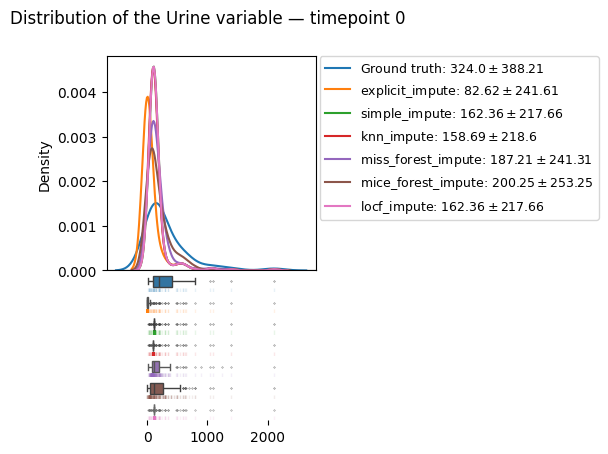

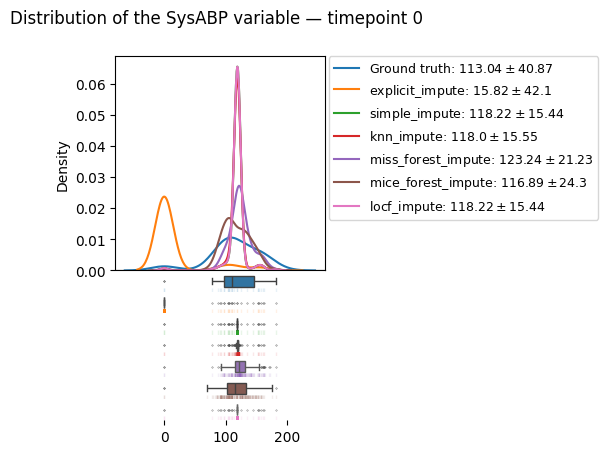

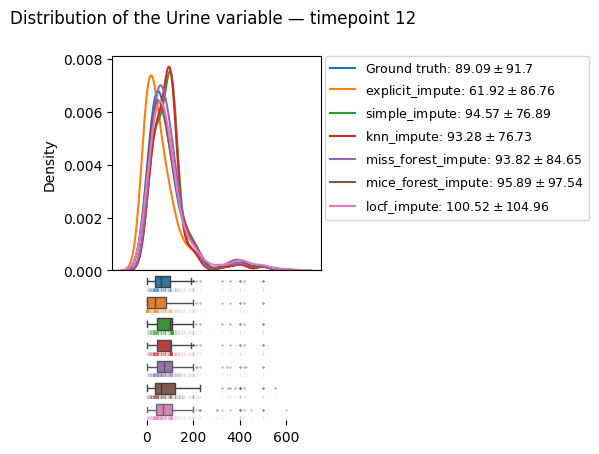

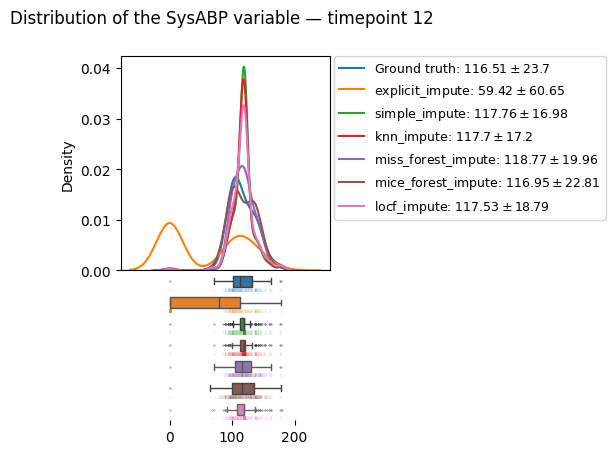

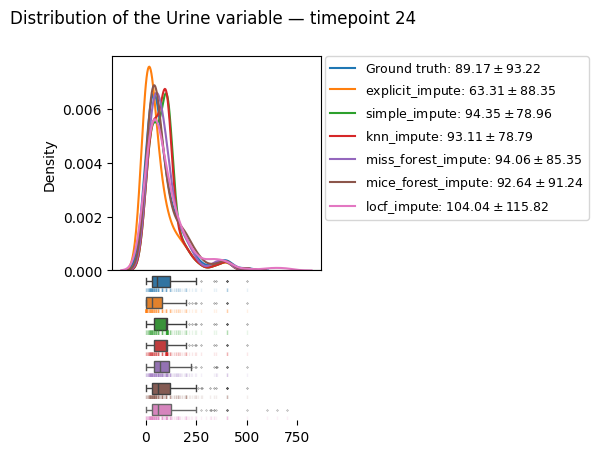

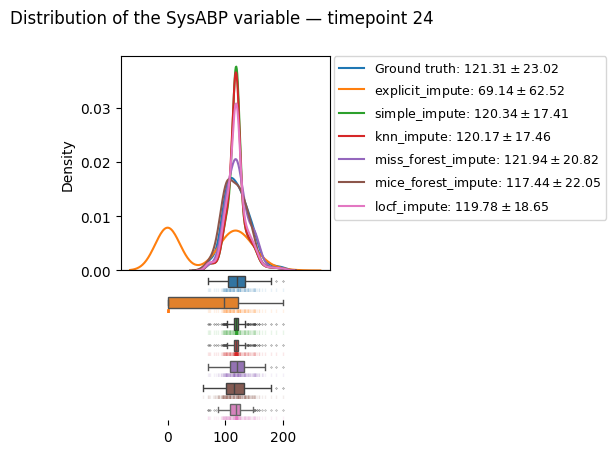

In [19]:
for t in TIMEPOINTS:
    edatas_at_t = []

    for e in [edata_bench, edata_explicit, edata_simple, edata_knn, edata_miss_forest, edata_mice_forest, edata_locf]:
        e_t = e[:, :, t].copy()          # 2D slice: obs × var
        X = e_t.layers["tem_data"].copy()
        X = X[:, :, 0]
        e_t.X = X
        edatas_at_t.append(e_t)

    for var in PLOT_VARS:
        distributions_plot(
            ["Ground truth", "explicit_impute",  "simple_impute", "knn_impute",
             "miss_forest_impute", "mice_forest_impute", "locf_impute"],
            edatas_at_t,
            var,
        )
        fig = plt.gcf()
        ax0 = fig.axes[0]
        handles, labels = ax0.get_legend_handles_labels()
        ax0.legend(handles, labels, fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        fig.set_size_inches(fig.get_size_inches() * 0.45)
        plt.suptitle(f"Distribution of the {var} variable — timepoint {t}")
    plt.show()  

### Key observations

Looking at these plots, we can clearly see the differences in how well each imputation method preserves the original distribution across both variables and all three timepoints.

`explicit_impute` performs poorest across all variables and timepoints. Replacing 
missing values with an explicit value introduces a large artificial peak at the replaced value that is absent in the ground truth, heavily distorting both the mean and shape. It should only be used when 
the replaced value carries a genuine clinical meaning.

`locf_impute` is the most shocking method despite having the stringest theoretical motivation for ICU time series data. The assumption that the last observed value is a good starting point for a missing value is clinically reasonable and it is fair to say that `locf_impute` improves over later timepoints as more prior observations accumulate. However, the variance collapses, if there is no prior observation (i. e  at t=0) to carry forward, or, at later timepoints, it occassionally carries forward extreme values inflating variance rather than preserving it, if the variable is not a stable variable. 

`simple_impute` is comparable to `locf_impute` in mean preservation but shares the collapsed variance problem. Filling all missing positions with the same mean/median/min/max value artificially makes the patients more similar than they actually are. 

`knn_impute` tracks the ground truth mean across all timepoints and variables but underestimates variance. This suggests, averaging over nearest neighbours smooths out the natural spread of the data.

`miss_forest_impute` performs well overall, preserving both mean and shape better than simpler methods. Its ability to model cross-variable relationships helps particularly for highly variant variables like Urine. 

`mice_forest_impute` is the best method for distribution preservation. By propagating uncertainty across multiple imputations, it naturally preserves variance better than a single forest fit and at t=12 and t=24 for SysABP, its standard deviations is the closest to ground truth of all methods. 


#### 4.3.3  Runtime and Memory Usage

Beyond accuracy, it is also important to consider the computational cost of each method. A method that performs well on 200 patients may become infeasible on the full dataset. We profile computational cost using [Scalene](https://github.com/plasma-labs/scalene), a Python profiler that reports both CPU time and memory usage at line-level granularity. The benchmark script is run externally across sample sizes of 1000, 5000 and 10000 patients:


## 5. Choose a Method

The right imputation method depends on what matters for your analysis and what computational resources are available. 

**If downstream analysis is sensitive to variance**: For downstream tasks such as PCA, clustering, survival modeling; using a method like `mice_forest_impute` and `miss_forest_impute` that preserves the spread of the data better than simpler methods is the right choice. This way, both methods avoid the artificial homogeneity introduced by mean based approaches. 

**If you need a fast, interpretable baseline**: `simple_impute` is the most transparent option and a reasonable choice for exploratory analysis or when downstream tasks are not sensitive to vairance compression.

**If working with variables changing slowly and being measured frequently**: `locf_impute` is suitable. But if working with early timepoints or very sparse data, be cautious with `locf_impute`, since it has nothing to carry forward at early timepoints. 

**If similarity within clusters is a strong signal in the cohort**: `knn_impute` works well, for example when patients clearly cluster into distinct clinical phenotypes. In this case, borrowing values from the most similar observations is more informative than a population level mean.

## 6. Apply Imputation to the Full Dataset

Based on the benchmarking results, we apply `mice_forest_impute` to the full dataset. While it is the most computationally expensive method, it best preserves the mean and variance of the original distributions in our dataset, which matters for any downstream analysis such as clustering or survival analysis. We also copy our original data so that we can do our sanity checks later on.

In [20]:
edata_original = edata.copy()
ep.pp.mice_forest_impute(edata, layer="tem_data")

## 7. After Imputation

After imputing, it is important to do two quick sanity checks:
- Value distributions should not shift dramatically
- Temporal trajectory for individual patients should look clinically plausible

To check whether value distributions shifted drammatically, we'll again use the distribution plots from bias_utils. This time, we'll look at original data and fully imputed data different variables at the time points t=0, t=12 and t=24.

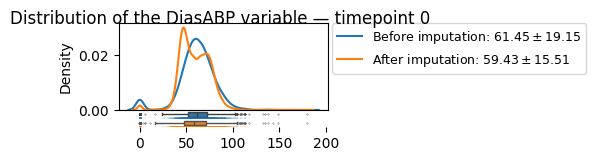

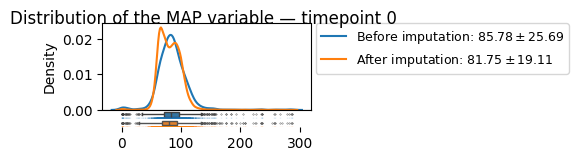

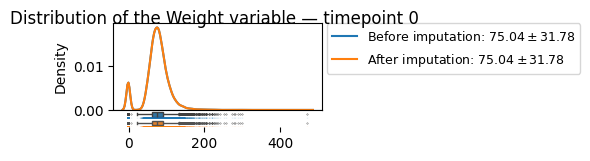

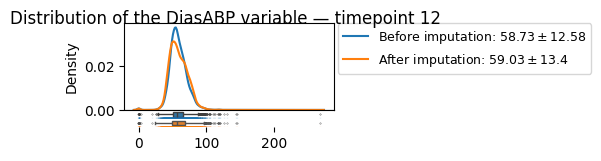

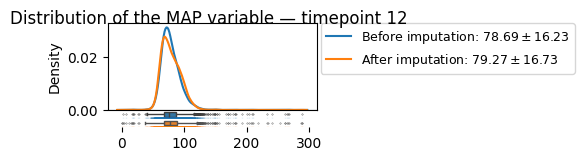

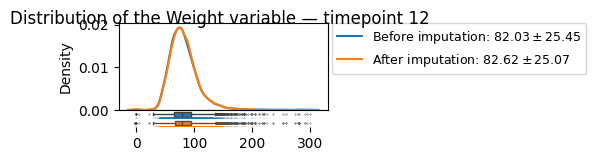

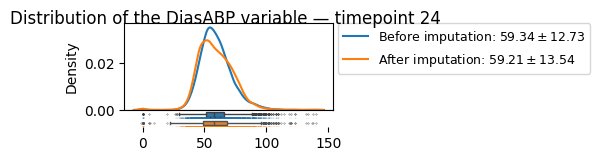

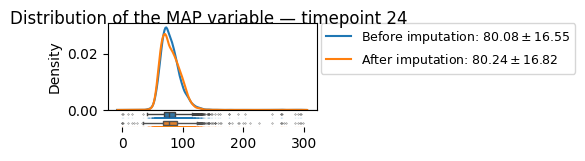

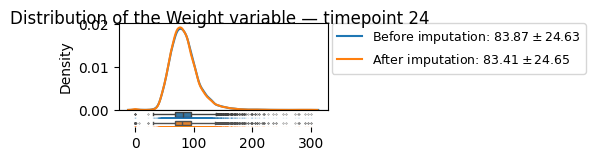

In [21]:
PLOT_VARS = miss_pct[(miss_pct > 20) & (miss_pct < 60)].sort_values().index.tolist()[2:5]

for t in TIMEPOINTS:
    edatas_at_t = []

    for e in [edata_original, edata]:
        e_t = e[:, :, t].copy()          # 2D slice: obs × var
        X = e_t.layers["tem_data"].copy()
        X = X[:, :, 0]
        e_t.X = X
        edatas_at_t.append(e_t)

    for var in PLOT_VARS:
        distributions_plot(
            ["Before imputation", "After imputation"],
            edatas_at_t,
            var,
        )
        fig = plt.gcf()
        ax0 = fig.axes[0]
        handles, labels = ax0.get_legend_handles_labels()
        ax0.legend(handles, labels, fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        fig.set_size_inches(fig.get_size_inches() * 0.45)
        plt.suptitle(f"Distribution of the {var} variable — timepoint {t}")
    plt.show() 